# JPEG File Size Analysis (Zarr)

This notebook analyzes the trade-off between JPEG compression quality, perceptual quality (LPIPS), and file size.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import lpips
from pathlib import Path
from tqdm import tqdm
import cv2
import h5py


In [36]:
# Initialize LPIPS model (uses AlexNet by default - faster than VGG)
lpips_model = lpips.LPIPS(net='alex')
if torch.cuda.is_available():
    lpips_model = lpips_model.cuda()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/ryan/Code/EgoVerse/emimic/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ryan/Code/EgoVerse/emimic/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/ryan/Code/EgoVerse/emimic/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


In [37]:
def load_sample_images(hdf5_dir: Path, num_samples: int = 50, image_compressed: bool = False) -> list[np.ndarray]:
    """Load sample images from HDF5 files."""
    hdf5_files = sorted(hdf5_dir.glob("*.hdf5"))[:5]  # Use first 5 episodes
    images = []
    
    def find_image_datasets(group, prefix=""):
        """Recursively find image datasets in HDF5 group."""
        datasets = []
        for key in group.keys():
            path = f"{prefix}/{key}" if prefix else key
            item = group[key]
            if isinstance(item, h5py.Dataset):
                if 'images' in path.lower():
                    datasets.append((path, item))
            elif isinstance(item, h5py.Group):
                datasets.extend(find_image_datasets(item, path))
        return datasets
    
    for hdf5_path in hdf5_files:
        if len(images) >= num_samples:
            break
        with h5py.File(hdf5_path, 'r') as f:
            # Find image datasets recursively
            image_datasets = find_image_datasets(f)
            if not image_datasets:
                print(f"No image datasets found in {hdf5_path}")
                continue
            
            # Use first image dataset found
            img_path, img_data = image_datasets[0]
            print(f"Using image dataset: {img_path}, shape: {img_data.shape}")
            
            # Sample frames evenly
            num_frames = img_data.shape[0]
            indices = np.linspace(0, num_frames - 1, min(10, num_frames), dtype=int)
            
            for idx in indices:
                if len(images) >= num_samples:
                    break
                img_raw = img_data[idx]
                if image_compressed:
                    # Decode JPEG/PNG
                    img_rgb = cv2.imdecode(img_raw, cv2.IMREAD_COLOR)
                    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
                else:
                    # Handle different shapes
                    if img_raw.ndim == 3:
                        if img_raw.shape[0] in (1, 3, 4):  # (C, H, W)
                            img_rgb = np.transpose(img_raw, (1, 2, 0))
                        else:  # Already (H, W, C)
                            img_rgb = img_raw
                    else:
                        img_rgb = img_raw
                    # Ensure RGB (3 channels)
                    if img_rgb.ndim == 3 and img_rgb.shape[2] == 1:
                        img_rgb = np.repeat(img_rgb, 3, axis=2)
                images.append(img_rgb.astype(np.uint8))
    
    return images

In [38]:
def compress_with_opencv_jpeg(image: np.ndarray, quality: int) -> tuple[int, np.ndarray]:
    """Compress image using OpenCV JPEG and return file size and decoded image."""
    # OpenCV expects BGR
    img_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    encode_params = [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)]
    ok, buffer = cv2.imencode('.jpg', img_bgr, encode_params)
    if not ok:
        raise RuntimeError('OpenCV JPEG encode failed')
    size_bytes = int(buffer.size)
    decoded_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    decoded_rgb = cv2.cvtColor(decoded_bgr, cv2.COLOR_BGR2RGB)
    return size_bytes, decoded_rgb


def compute_lpips(img1: np.ndarray, img2: np.ndarray, model: lpips.LPIPS) -> float:
    """Compute LPIPS between two images."""
    # Convert to torch tensors: (H, W, C) -> (1, C, H, W), normalize to [-1, 1]
    t1 = torch.from_numpy(img1).permute(2, 0, 1).unsqueeze(0).float() / 127.5 - 1
    t2 = torch.from_numpy(img2).permute(2, 0, 1).unsqueeze(0).float() / 127.5 - 1
    
    if torch.cuda.is_available():
        t1, t2 = t1.cuda(), t2.cuda()
    
    with torch.no_grad():
        score = model(t1, t2)
    
    return score.item()


In [39]:
# Load sample images
# Update this path to your HDF5 directory
HDF5_DIR = Path("raw")  # Adjust as needed
IMAGE_COMPRESSED = False  # Set to True if images in HDF5 are JPEG/PNG compressed

print(f"Loading images from {HDF5_DIR}...")
images = load_sample_images(HDF5_DIR, num_samples=50, image_compressed=IMAGE_COMPRESSED)
print(f"Loaded {len(images)} images")

if images:
    print(f"Image shape: {images[0].shape}, dtype: {images[0].dtype}")

Loading images from raw...
Using image dataset: observations/images/front_img_1, shape: (373, 480, 640, 3)
Using image dataset: observations/images/front_img_1, shape: (265, 480, 640, 3)
Using image dataset: observations/images/front_img_1, shape: (269, 480, 640, 3)
Using image dataset: observations/images/front_img_1, shape: (251, 480, 640, 3)
Using image dataset: observations/images/front_img_1, shape: (251, 480, 640, 3)
Loaded 50 images
Image shape: (480, 640, 3), dtype: uint8


In [40]:
# Test quality levels
quality_levels = [10, 20, 30, 40, 50, 60, 70, 80, 85, 90, 95, 100]

def init_results():
    return {
        'quality': [],
        'lpips_mean': [],
        'lpips_std': [],
        'size_kb_mean': [],
        'size_kb_std': [],
        'psnr_mean': [],
        'psnr_std': [],
    }

results = {
    'jpeg': init_results(),
}

def run_quality_sweep(codec_name: str, compress_fn):
    for quality in tqdm(quality_levels, desc=f"Testing {codec_name} quality levels"):
        lpips_scores = []
        sizes_kb = []
        psnr_scores = []
        
        for img in images:
            size_bytes, decoded = compress_fn(img, quality)
            
            # File size
            size_kb = size_bytes / 1024
            sizes_kb.append(size_kb)
            
            # LPIPS
            lpips_score = compute_lpips(img, decoded, lpips_model)
            lpips_scores.append(lpips_score)
            
            # PSNR
            mse = np.mean((img.astype(float) - decoded.astype(float)) ** 2)
            if mse > 0:
                psnr = 10 * np.log10(255**2 / mse)
            else:
                psnr = float('inf')
            psnr_scores.append(psnr)
        
        results[codec_name]['quality'].append(quality)
        results[codec_name]['lpips_mean'].append(np.mean(lpips_scores))
        results[codec_name]['lpips_std'].append(np.std(lpips_scores))
        results[codec_name]['size_kb_mean'].append(np.mean(sizes_kb))
        results[codec_name]['size_kb_std'].append(np.std(sizes_kb))
        results[codec_name]['psnr_mean'].append(np.mean(psnr_scores))
        results[codec_name]['psnr_std'].append(np.std(psnr_scores))
        
        print(
            f"{codec_name.upper()} Q={quality:3d}: LPIPS={np.mean(lpips_scores):.4f}, "
            f"Size={np.mean(sizes_kb):.1f}KB, PSNR={np.mean(psnr_scores):.1f}dB"
        )

run_quality_sweep('jpeg', compress_with_opencv_jpeg)


Testing jpeg quality levels:   8%|▊         | 1/12 [00:00<00:05,  1.85it/s]

JPEG Q= 10: LPIPS=0.3370, Size=8.9KB, PSNR=30.2dB


Testing jpeg quality levels:  17%|█▋        | 2/12 [00:01<00:05,  1.89it/s]

JPEG Q= 20: LPIPS=0.2301, Size=12.0KB, PSNR=32.7dB


Testing jpeg quality levels:  25%|██▌       | 3/12 [00:01<00:04,  1.83it/s]

...

JPEG Q= 90: LPIPS=0.0279, Size=57.8KB, PSNR=38.5dB


Testing jpeg quality levels:  92%|█████████▏| 11/12 [00:06<00:00,  1.65it/s]

JPEG Q= 95: LPIPS=0.0153, Size=89.3KB, PSNR=40.0dB


Testing jpeg quality levels: 100%|██████████| 12/12 [00:07<00:00,  1.60it/s]

JPEG Q=100: LPIPS=0.0063, Size=216.5KB, PSNR=44.4dB


In [41]:
# Calculate uncompressed size for reference
if images:
    uncompressed_kb = images[0].nbytes / 1024
    print(f"Uncompressed image size: {uncompressed_kb:.1f} KB")

Uncompressed image size: 900.0 KB


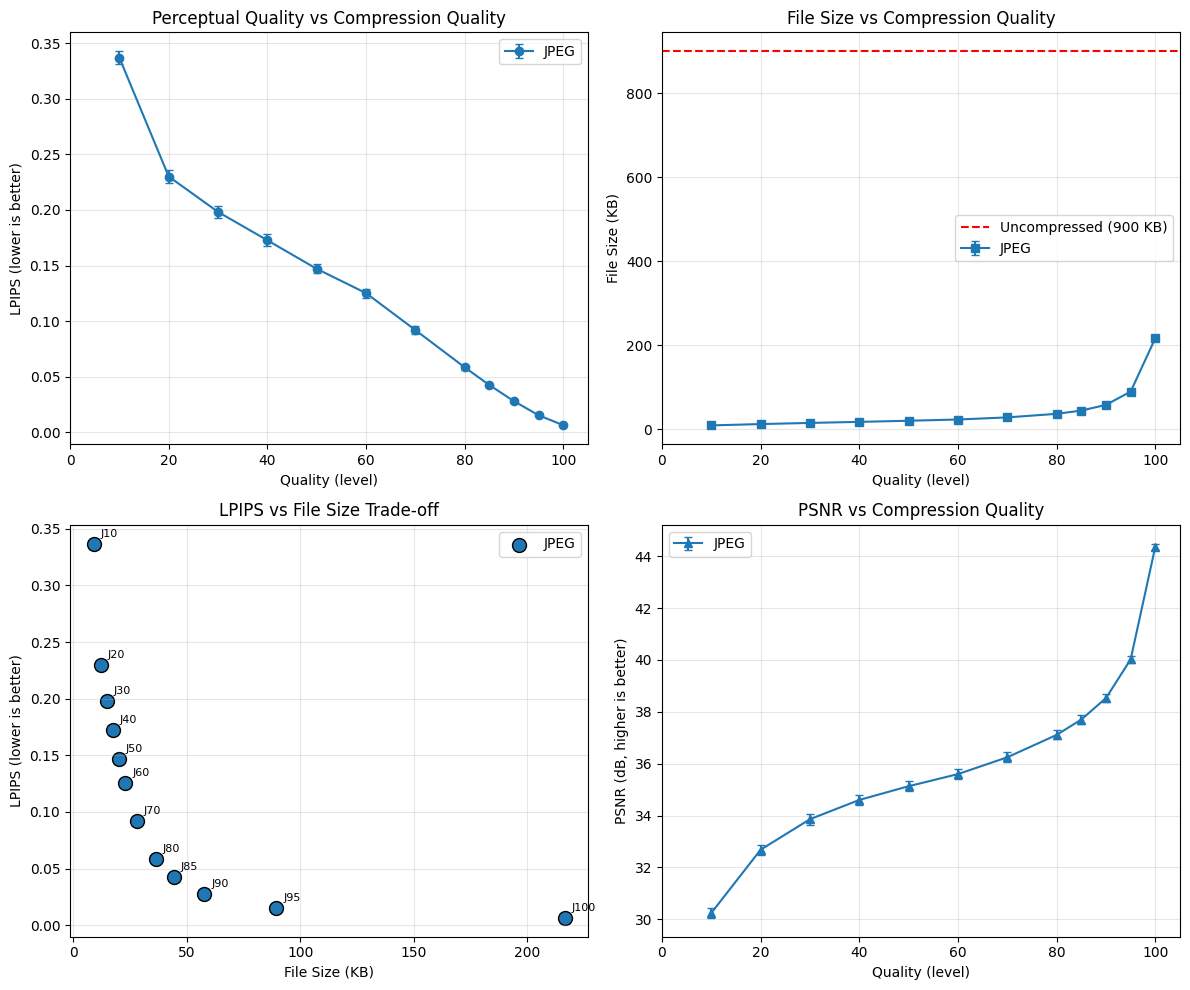

In [42]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: LPIPS vs Quality
ax1 = axes[0, 0]
ax1.errorbar(results['jpeg']['quality'], results['jpeg']['lpips_mean'], yerr=results['jpeg']['lpips_std'], 
             marker='o', capsize=3, color='tab:blue', label='JPEG')
ax1.set_xlabel('Quality (level)')
ax1.set_ylabel('LPIPS (lower is better)')
ax1.set_title('Perceptual Quality vs Compression Quality')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 105)
ax1.legend()

# Plot 2: File Size vs Quality
ax2 = axes[0, 1]
ax2.errorbar(results['jpeg']['quality'], results['jpeg']['size_kb_mean'], yerr=results['jpeg']['size_kb_std'],
             marker='s', capsize=3, color='tab:blue', label='JPEG')
if images:
    ax2.axhline(y=uncompressed_kb, color='red', linestyle='--', label=f'Uncompressed ({uncompressed_kb:.0f} KB)')
ax2.set_xlabel('Quality (level)')
ax2.set_ylabel('File Size (KB)')
ax2.set_title('File Size vs Compression Quality')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlim(0, 105)

# Plot 3: LPIPS vs File Size (main trade-off plot)
ax3 = axes[1, 0]
ax3.scatter(results['jpeg']['size_kb_mean'], results['jpeg']['lpips_mean'], 
            color='tab:blue', s=100, edgecolors='black', label='JPEG')
for i, q in enumerate(results['jpeg']['quality']):
    ax3.annotate(f'J{q}', (results['jpeg']['size_kb_mean'][i], results['jpeg']['lpips_mean'][i]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
ax3.set_xlabel('File Size (KB)')
ax3.set_ylabel('LPIPS (lower is better)')
ax3.set_title('LPIPS vs File Size Trade-off')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: PSNR vs Quality
ax4 = axes[1, 1]
ax4.errorbar(results['jpeg']['quality'], results['jpeg']['psnr_mean'], yerr=results['jpeg']['psnr_std'],
             marker='^', capsize=3, color='tab:blue', label='JPEG')
ax4.set_xlabel('Quality (level)')
ax4.set_ylabel('PSNR (dB, higher is better)')
ax4.set_title('PSNR vs Compression Quality')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 105)
ax4.legend()

plt.tight_layout()
plt.savefig('jpeg_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [43]:
# Summary table
import pandas as pd

def make_df(res):
    return pd.DataFrame({
        'Quality': res['quality'],
        'LPIPS': [f"{m:.4f} ± {s:.4f}" for m, s in zip(res['lpips_mean'], res['lpips_std'])],
        'Size KB': [f"{m:.1f} ± {s:.1f}" for m, s in zip(res['size_kb_mean'], res['size_kb_std'])],
        'PSNR (dB)': [f"{m:.1f} ± {s:.1f}" for m, s in zip(res['psnr_mean'], res['psnr_std'])],
    })

print('JPEG results')
display(make_df(results['jpeg']))


JPEG results


,Quality,LPIPS,Size KB,PSNR (dB)
0,10,0.3370 ± 0.0060,8.9 ± 0.3,30.2 ± 0.2
1,20,0.2301 ± 0.0057,12.0 ± 0.4,32.7 ± 0.2
2,30,0.1983 ± 0.0057,14.8 ± 0.5,33.9 ± 0.2
3,40,0.1727 ± 0.0053,17.3 ± 0.6,34.6 ± 0.2
4,50,0.1471 ± 0.0042,19.9 ± 0.8,35.1 ± 0.2
5,60,0.1252 ± 0.0040,22.9 ± 0.9,35.6 ± 0.2
6,70,0.0919 ± 0.0033,27.9 ± 1.1,36.2 ± 0.2
7,80,0.0584 ± 0.0019,36.4 ± 1.3,37.1 ± 0.2
8,85,0.0425 ± 0.0014,44.1 ± 1.5,37.7 ± 0.2
9,90,0.0279 ± 0.0009,57.8 ± 1.8,38.5 ± 0.2


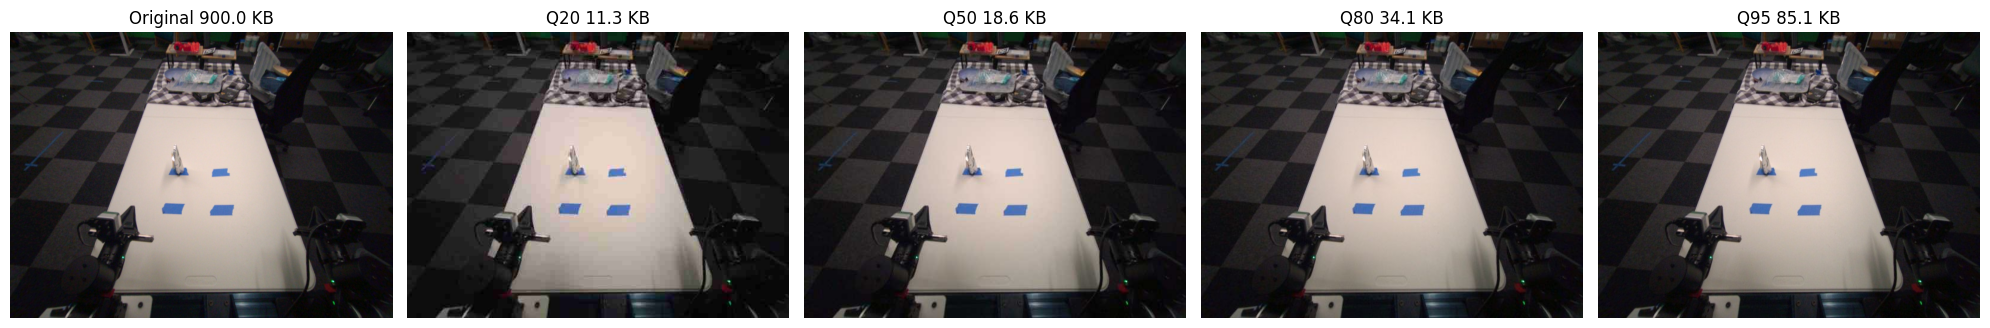

In [44]:
# Visual comparison at different quality levels
if images:
    sample_img = images[0]
    compare_qualities = [20, 50, 80, 95]
    
    fig, axes = plt.subplots(1, len(compare_qualities) + 1, figsize=(4 * (len(compare_qualities) + 1), 4))
    
    # Original
    axes[0].imshow(sample_img)
    axes[0].set_title(f'Original {sample_img.nbytes/1024:.1f} KB')
    axes[0].axis('off')
    
    # Compressed JPEG
    for i, quality in enumerate(compare_qualities):
        size_bytes, decoded = compress_with_opencv_jpeg(sample_img, quality)
        axes[i+1].imshow(decoded)
        axes[i+1].set_title(f"Q{quality} {size_bytes/1024:.1f} KB")
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
